In [2]:
%pip install scipy statsmodels

  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/95/da/0d1df507cf574b3f224ccc3d45244c9a1d732c81dcb26b1e8a766ae271a8/scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 465.2 kB/s eta 0:00:00
  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/b8/be/77c4b5d3f61eab5676981d20f705acee8222ad31de8aca42a331dcd4cfdb/statsmodels-0.15.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for patsy>=0.5.6 from https://files.pythonhosted.org/packages/f1/70/ba4b949bdc0490ab78d545459acd7702b211dfccf7eb89bbc1060f52818d/patsy-1.0.2-py2.py3-none-any.whl.metadata
  Obtaining dependency information for formulaic>=1.1.0 from https:


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/bc/be/fa26ed085b41298f64a8f9b7592c671bbf1acc8b0df124c1c5de96b859f8/matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 262.6 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 560.2 kB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/98/4b/9bd370b004b5c9d8045c6c33cf65bae018b27aca550a3f657cdc99acdbd8/contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.28.2 


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Statistical Finding 1: Encounter Volume vs Wait Time

In [5]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

from scipy import stats
from scipy.stats import (
    pearsonr,
    spearmanr,
    chi2_contingency,
    ttest_ind
)

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [6]:
server = r"localhost\SQLEXPRESS"
database = "rivercare_analytics"

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

print("SQL Server connection engine created successfully.")

SQL Server connection engine created successfully.


In [7]:
test_query = """
SELECT TOP 5 *
FROM dbo.fact_encounter;
"""

test_df = pd.read_sql(test_query, engine)

test_df

,EncounterKey,EncounterID,PatientKey,ProviderKey,DepartmentKey,PayerKey,EncounterDateKey,EncounterType,EncounterStatus,ArrivalDateTime,TriageDateTime,ProviderStartDateTime,EncounterEndDateTime,EncounterCost,WaitMinutes,EncounterDurationHours,PatientIDValidFlag,ProviderIDValidFlag,DepartmentIDValidFlag,DepartmentIDRecoveredFlag,DepartmentIDResolvedFlag,EncounterCostValidFlag,WaitTimeValidFlag,EncounterDurationValidFlag,EncounterEndRecoveredFlag,EncounterQualityFlag
0,1,ENC000001,3051,51,7,3,20240619,Emergency,Completed,2024-06-19 02:35:00,2024-06-19 02:52:00,2024-06-19 03:06:00,2026-08-28 23:40:48,"1,067.62",31.00,"19,221.10",1,1.00,1,0,1,1,1,1,0,1
1,2,ENC000002,5787,0,20,1,20251125,Outpatient,Completed,2025-11-25 13:46:00,NaT,2025-11-25 14:00:00,NaT,385.01,14.00,NaN,1,NaN,1,0,1,1,1,0,0,1
2,3,ENC000003,9802,118,1,6,20251001,Emergency,Completed,2025-10-01 18:12:00,2025-10-01 18:36:00,2025-10-01 20:03:00,NaT,"2,056.60",111.00,NaN,1,1.00,1,0,1,1,1,0,0,1
3,4,ENC000004,2454,32,14,5,20230511,Specialist,Completed,2023-05-11 14:45:00,NaT,2023-05-11 15:00:00,NaT,567.31,15.00,NaN,1,1.00,1,0,1,1,1,0,0,1
4,5,ENC000005,3934,8,22,3,20251216,Outpatient,Completed,2025-12-16 15:46:00,NaT,2025-12-16 16:28:00,NaT,258.00,42.00,NaN,1,1.00,1,0,1,1,1,0,0,1


### Load Department-Month Metrics

In [8]:
volume_wait_query = """
SELECT
    d.DepartmentName,
    dt.Year,
    dt.Month,
    dt.YearMonth,

    COUNT(*) AS TotalEncounters,

    AVG(f.WaitMinutes) AS AverageWaitMinutes

FROM dbo.fact_encounter AS f

INNER JOIN dbo.dim_department AS d
    ON f.DepartmentKey = d.DepartmentKey

INNER JOIN dbo.dim_date AS dt
    ON f.EncounterDateKey = dt.DateKey

WHERE
    f.DepartmentKey <> 0
    AND f.EncounterDateKey <> 0
    AND f.WaitMinutes IS NOT NULL

GROUP BY
    d.DepartmentName,
    dt.Year,
    dt.Month,
    dt.YearMonth

ORDER BY
    d.DepartmentName,
    dt.Year,
    dt.Month;
"""

volume_wait_df = pd.read_sql(volume_wait_query, engine)

volume_wait_df.head(10)

,DepartmentName,Year,Month,YearMonth,TotalEncounters,AverageWaitMinutes
0,Behavioral Health,2023,1,2023-01,1,8.00
1,Behavioral Health,2023,2,2023-02,7,36.43
2,Behavioral Health,2023,3,2023-03,8,23.25
3,Behavioral Health,2023,4,2023-04,12,22.17
4,Behavioral Health,2023,5,2023-05,13,30.69
5,Behavioral Health,2023,6,2023-06,13,27.77
6,Behavioral Health,2023,7,2023-07,25,30.28
7,Behavioral Health,2023,8,2023-08,22,33.55
8,Behavioral Health,2023,9,2023-09,25,26.16
9,Behavioral Health,2023,10,2023-10,39,30.56


### Check Data Quality and Basic Statistics

In [9]:
print("Number of department-month observations:", len(volume_wait_df))

print("\nMissing values:")
print(
    volume_wait_df[
        ["TotalEncounters", "AverageWaitMinutes"]
    ].isnull().sum()
)

print("\nDescriptive statistics:")

volume_wait_df[
    ["TotalEncounters", "AverageWaitMinutes"]
].describe()

Number of department-month observations: 429

Missing values:
TotalEncounters       0
AverageWaitMinutes    0
dtype: int64

Descriptive statistics:


,TotalEncounters,AverageWaitMinutes
count,429.00,429.00
mean,207.07,31.35
std,271.00,14.25
min,1.00,6.00
25%,44.00,25.07
50%,112.00,26.64
75%,248.00,29.78
max,"2,296.00",96.67


### Scatter Plot: Encounter Volume vs Wait Time

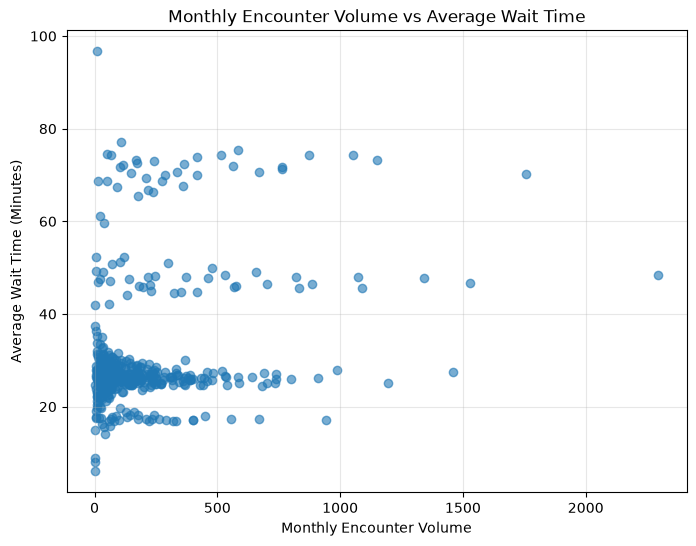

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    volume_wait_df["TotalEncounters"],
    volume_wait_df["AverageWaitMinutes"],
    alpha=0.6
)

plt.xlabel("Monthly Encounter Volume")
plt.ylabel("Average Wait Time (Minutes)")
plt.title("Monthly Encounter Volume vs Average Wait Time")

plt.grid(alpha=0.3)

plt.show()

### Calculate Pearson and Spearman Correlations

In [11]:
analysis_df = volume_wait_df[
    ["TotalEncounters", "AverageWaitMinutes"]
].dropna()

pearson_r, pearson_p = pearsonr(
    analysis_df["TotalEncounters"],
    analysis_df["AverageWaitMinutes"]
)

spearman_r, spearman_p = spearmanr(
    analysis_df["TotalEncounters"],
    analysis_df["AverageWaitMinutes"]
)

print("Pearson Correlation")
print(f"r-value: {pearson_r:.3f}")
print(f"p-value: {pearson_p:.4f}")

print("\nSpearman Correlation")
print(f"rho-value: {spearman_r:.3f}")
print(f"p-value: {spearman_p:.4f}")

Pearson Correlation
r-value: 0.285
p-value: 0.0000

Spearman Correlation
rho-value: 0.127
p-value: 0.0084


### Within-Department Volume vs Wait Time

In [12]:
within_department_df = volume_wait_df.copy()

within_department_df["VolumeDeviation"] = (
    within_department_df["TotalEncounters"]
    - within_department_df.groupby("DepartmentName")["TotalEncounters"].transform("mean")
)

within_department_df["WaitDeviation"] = (
    within_department_df["AverageWaitMinutes"]
    - within_department_df.groupby("DepartmentName")["AverageWaitMinutes"].transform("mean")
)

within_department_df[
    [
        "DepartmentName",
        "YearMonth",
        "TotalEncounters",
        "AverageWaitMinutes",
        "VolumeDeviation",
        "WaitDeviation"
    ]
].head(10)

,DepartmentName,YearMonth,TotalEncounters,AverageWaitMinutes,VolumeDeviation,WaitDeviation
0,Behavioral Health,2023-01,1,8.00,-117.75,-19.21
1,Behavioral Health,2023-02,7,36.43,-111.75,9.22
2,Behavioral Health,2023-03,8,23.25,-110.75,-3.96
3,Behavioral Health,2023-04,12,22.17,-106.75,-5.04
4,Behavioral Health,2023-05,13,30.69,-105.75,3.48
5,Behavioral Health,2023-06,13,27.77,-105.75,0.56
6,Behavioral Health,2023-07,25,30.28,-93.75,3.07
7,Behavioral Health,2023-08,22,33.55,-96.75,6.34
8,Behavioral Health,2023-09,25,26.16,-93.75,-1.05
9,Behavioral Health,2023-10,39,30.56,-79.75,3.36


### Within-Department Correlation

In [13]:
within_pearson_r, within_pearson_p = pearsonr(
    within_department_df["VolumeDeviation"],
    within_department_df["WaitDeviation"]
)

within_spearman_r, within_spearman_p = spearmanr(
    within_department_df["VolumeDeviation"],
    within_department_df["WaitDeviation"]
)

print("Within-Department Pearson Correlation")
print(f"r-value: {within_pearson_r:.3f}")
print(f"p-value: {within_pearson_p:.4f}")

print("\nWithin-Department Spearman Correlation")
print(f"rho-value: {within_spearman_r:.3f}")
print(f"p-value: {within_spearman_p:.4f}")

Within-Department Pearson Correlation
r-value: -0.009
p-value: 0.8478

Within-Department Spearman Correlation
rho-value: 0.010
p-value: 0.8414


### Statistical Finding 1: Encounter Volume vs Wait Time

The initial pooled analysis showed a statistically significant but weak positive
association between monthly encounter volume and average wait time
(Pearson r = 0.285, p < 0.001; Spearman ρ = 0.127, p = 0.0084).

However, the scatter plot showed clear department-level clustering. After centering
monthly volume and wait time around each department's own average, the relationship
disappeared (Pearson r = -0.009, p = 0.8478; Spearman ρ = 0.010, p = 0.8414).

This suggests that the pooled association was primarily driven by differences in
baseline volume and wait times between departments rather than by month-to-month
changes in encounter volume within the same department.

Therefore, encounter volume alone does not appear to explain monthly wait-time
variation within departments. Other operational factors should be investigated.

This analysis identifies association only and does not establish causation.

### Statistical Analysis 2 — Provider Workload vs Wait Time

### Load Provider Workload Dataset

In [14]:
provider_workload_query = """
SELECT
    d.DepartmentName,
    dt.Year,
    dt.Month,
    dt.YearMonth,

    COUNT(*) AS TotalEncounters,

    COUNT(
        DISTINCT f.ProviderKey
    ) AS ActiveProviders,

    1.0 * COUNT(*)
    /
    NULLIF(
        COUNT(DISTINCT f.ProviderKey),
        0
    ) AS EncountersPerProvider,

    AVG(
        f.WaitMinutes
    ) AS AverageWaitMinutes

FROM dbo.fact_encounter AS f

INNER JOIN dbo.dim_department AS d
    ON f.DepartmentKey = d.DepartmentKey

INNER JOIN dbo.dim_date AS dt
    ON f.EncounterDateKey = dt.DateKey

WHERE
    f.DepartmentKey <> 0
    AND f.ProviderKey <> 0
    AND f.EncounterDateKey <> 0
    AND f.WaitMinutes IS NOT NULL

GROUP BY
    d.DepartmentName,
    dt.Year,
    dt.Month,
    dt.YearMonth

ORDER BY
    d.DepartmentName,
    dt.Year,
    dt.Month;
"""

provider_workload_df = pd.read_sql(
    provider_workload_query,
    engine
)

provider_workload_df.head(10)

,DepartmentName,Year,Month,YearMonth,TotalEncounters,ActiveProviders,EncountersPerProvider,AverageWaitMinutes
0,Behavioral Health,2023,2,2023-02,7,7,1.00,36.43
1,Behavioral Health,2023,3,2023-03,8,5,1.60,23.25
2,Behavioral Health,2023,4,2023-04,12,8,1.50,22.17
3,Behavioral Health,2023,5,2023-05,13,8,1.62,30.69
4,Behavioral Health,2023,6,2023-06,11,7,1.57,21.73
5,Behavioral Health,2023,7,2023-07,25,9,2.78,30.28
6,Behavioral Health,2023,8,2023-08,22,8,2.75,33.55
7,Behavioral Health,2023,9,2023-09,25,9,2.78,26.16
8,Behavioral Health,2023,10,2023-10,39,8,4.88,30.56
9,Behavioral Health,2023,11,2023-11,43,9,4.78,28.44


### Check Provider Workload Data

In [15]:
print("Number of department-month observations:", len(provider_workload_df))

print("\nMissing values:")
print(
    provider_workload_df[
        [
            "ActiveProviders",
            "EncountersPerProvider",
            "AverageWaitMinutes"
        ]
    ].isnull().sum()
)

print("\nDescriptive statistics:")

provider_workload_df[
    [
        "TotalEncounters",
        "ActiveProviders",
        "EncountersPerProvider",
        "AverageWaitMinutes"
    ]
].describe()

Number of department-month observations: 428

Missing values:
ActiveProviders          0
EncountersPerProvider    0
AverageWaitMinutes       0
dtype: int64

Descriptive statistics:


,TotalEncounters,ActiveProviders,EncountersPerProvider,AverageWaitMinutes
count,428.00,428.00,428.00,428.00
mean,205.48,9.61,19.82,31.41
std,268.69,4.23,21.21,14.26
min,1.00,1.00,1.00,6.00
25%,45.50,5.00,5.44,25.01
50%,112.00,9.00,12.97,26.62
75%,246.00,13.00,26.10,29.74
max,"2,273.00",18.00,151.53,96.67


### Scatter Plot: Provider Workload vs Wait Time

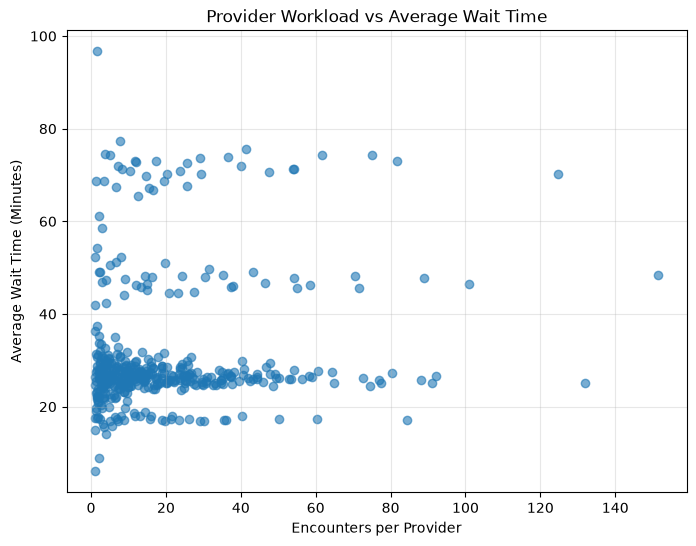

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    provider_workload_df["EncountersPerProvider"],
    provider_workload_df["AverageWaitMinutes"],
    alpha=0.6
)

plt.xlabel("Encounters per Provider")
plt.ylabel("Average Wait Time (Minutes)")
plt.title("Provider Workload vs Average Wait Time")

plt.grid(alpha=0.3)

plt.show()

There is no clear linear pattern

### Calculate Pearson and Spearman Correlations

In [17]:
provider_analysis_df = provider_workload_df[
    ["EncountersPerProvider", "AverageWaitMinutes"]
].dropna()

provider_pearson_r, provider_pearson_p = pearsonr(
    provider_analysis_df["EncountersPerProvider"],
    provider_analysis_df["AverageWaitMinutes"]
)

provider_spearman_r, provider_spearman_p = spearmanr(
    provider_analysis_df["EncountersPerProvider"],
    provider_analysis_df["AverageWaitMinutes"]
)

print("Provider Workload - Pearson Correlation")
print(f"r-value: {provider_pearson_r:.3f}")
print(f"p-value: {provider_pearson_p:.4f}")

print("\nProvider Workload - Spearman Correlation")
print(f"rho-value: {provider_spearman_r:.3f}")
print(f"p-value: {provider_spearman_p:.4f}")

Provider Workload - Pearson Correlation
r-value: 0.151
p-value: 0.0017

Provider Workload - Spearman Correlation
rho-value: 0.080
p-value: 0.0970


### Check the Relationship Within Departments

In [18]:
provider_within_df = provider_workload_df.copy()

provider_within_df["WorkloadDeviation"] = (
    provider_within_df["EncountersPerProvider"]
    - provider_within_df.groupby("DepartmentName")[
        "EncountersPerProvider"
    ].transform("mean")
)

provider_within_df["WaitDeviation"] = (
    provider_within_df["AverageWaitMinutes"]
    - provider_within_df.groupby("DepartmentName")[
        "AverageWaitMinutes"
    ].transform("mean")
)

provider_within_df[
    [
        "DepartmentName",
        "YearMonth",
        "EncountersPerProvider",
        "AverageWaitMinutes",
        "WorkloadDeviation",
        "WaitDeviation"
    ]
].head(10)

,DepartmentName,YearMonth,EncountersPerProvider,AverageWaitMinutes,WorkloadDeviation,WaitDeviation
0,Behavioral Health,2023-02,1.00,36.43,-12.49,8.87
1,Behavioral Health,2023-03,1.60,23.25,-11.89,-4.31
2,Behavioral Health,2023-04,1.50,22.17,-11.99,-5.39
3,Behavioral Health,2023-05,1.62,30.69,-11.87,3.13
4,Behavioral Health,2023-06,1.57,21.73,-11.92,-5.83
5,Behavioral Health,2023-07,2.78,30.28,-10.72,2.72
6,Behavioral Health,2023-08,2.75,33.55,-10.74,5.99
7,Behavioral Health,2023-09,2.78,26.16,-10.72,-1.40
8,Behavioral Health,2023-10,4.88,30.56,-8.62,3.01
9,Behavioral Health,2023-11,4.78,28.44,-8.72,0.88


### Within-Department Workload Correlation

In [19]:
within_provider_pearson_r, within_provider_pearson_p = pearsonr(
    provider_within_df["WorkloadDeviation"],
    provider_within_df["WaitDeviation"]
)

within_provider_spearman_r, within_provider_spearman_p = spearmanr(
    provider_within_df["WorkloadDeviation"],
    provider_within_df["WaitDeviation"]
)

print("Within-Department Provider Workload - Pearson Correlation")
print(f"r-value: {within_provider_pearson_r:.3f}")
print(f"p-value: {within_provider_pearson_p:.4f}")

print("\nWithin-Department Provider Workload - Spearman Correlation")
print(f"rho-value: {within_provider_spearman_r:.3f}")
print(f"p-value: {within_provider_spearman_p:.4f}")

Within-Department Provider Workload - Pearson Correlation
r-value: -0.015
p-value: 0.7555

Within-Department Provider Workload - Spearman Correlation
rho-value: -0.003
p-value: 0.9543


### Statistical Finding 2: Provider Workload vs Wait Time

The pooled analysis showed a weak positive linear association between provider
workload and average wait time (Pearson r = 0.151, p = 0.0017). However, the
Spearman correlation was very weak and not statistically significant
(ρ = 0.080, p = 0.0970).

After centering provider workload and wait time around each department's own
average, the relationship disappeared (Pearson r = -0.015, p = 0.7555;
Spearman ρ = -0.003, p = 0.9543).

This suggests that the pooled relationship was primarily influenced by
differences between departments or extreme observations rather than a
consistent month-to-month relationship within departments.

Therefore, encounters per provider alone does not appear to explain wait-time
variation within departments. Additional operational factors should be
investigated.

This workload measure is a proxy based on encounter counts and active providers
and does not represent true staffing capacity or utilization.

## Statistical Analysis 3 — Booking Lead Time vs No-Show

### Load Appointment-Level Data

In [20]:
appointment_query = """
SELECT
    a.AppointmentKey,
    a.DepartmentKey,
    d.DepartmentName,
    a.BookingLeadDays,
    a.AppointmentStatus

FROM dbo.fact_appointment AS a

INNER JOIN dbo.dim_department AS d
    ON a.DepartmentKey = d.DepartmentKey

WHERE
    a.DepartmentKey <> 0
    AND a.BookingLeadDays IS NOT NULL
    AND a.AppointmentStatus IN (
        'Completed',
        'No Show',
        'Cancelled'
    );
"""

appointment_df = pd.read_sql(
    appointment_query,
    engine
)

appointment_df.head(10)

,AppointmentKey,DepartmentKey,DepartmentName,BookingLeadDays,AppointmentStatus
0,1,25,Orthopedics,12.00,Completed
1,2,4,Neurology,14.00,Completed
2,3,21,Primary Care,56.00,Completed
3,4,19,Endocrinology,59.00,Cancelled
4,5,9,Cardiology,3.00,Completed
5,6,18,Behavioral Health,6.00,Completed
6,7,22,Pediatrics,41.00,Completed
7,8,6,Oncology,27.00,No Show
8,9,22,Pediatrics,26.00,Completed
9,10,20,Cardiology,6.00,Completed


### Check Appointment Data

In [21]:
print("Number of appointments:", len(appointment_df))

print("\nMissing values:")
print(
    appointment_df[
        ["BookingLeadDays", "AppointmentStatus"]
    ].isnull().sum()
)

print("\nAppointment status counts:")
print(
    appointment_df["AppointmentStatus"]
    .value_counts()
)

print("\nBooking lead time statistics:")
print(
    appointment_df["BookingLeadDays"]
    .describe()
)

Number of appointments: 46776

Missing values:
BookingLeadDays      0
AppointmentStatus    0
dtype: int64

Appointment status counts:
AppointmentStatus
Completed    36900
Cancelled     5002
No Show       4874
Name: count, dtype: int64

Booking lead time statistics:
count   46,776.00
mean        25.56
std         16.78
min          0.00
25%         12.00
50%         23.00
75%         37.00
max         75.00
Name: BookingLeadDays, dtype: float64


### Create No-Show vs Completed Groups

In [22]:
no_show_df = appointment_df[
    appointment_df["AppointmentStatus"].isin(
        ["Completed", "No Show"]
    )
].copy()

no_show_df["NoShowFlag"] = np.where(
    no_show_df["AppointmentStatus"] == "No Show",
    1,
    0
)

print("Appointments included in analysis:", len(no_show_df))

print("\nGroup counts:")
print(
    no_show_df["AppointmentStatus"]
    .value_counts()
)

print("\nBooking lead time by appointment outcome:")

group_summary = (
    no_show_df
    .groupby("AppointmentStatus")["BookingLeadDays"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        StdDev="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

group_summary

Appointments included in analysis: 41774

Group counts:
AppointmentStatus
Completed    36900
No Show       4874
Name: count, dtype: int64

Booking lead time by appointment outcome:


,Count,Mean,Median,StdDev,Minimum,Maximum
AppointmentStatus,,,,,,
Completed,36900,24.97,23.00,16.56,0.00,75.00
No Show,4874,29.81,31.00,17.79,0.00,75.00


### Visualize Booking Lead Time by Outcome

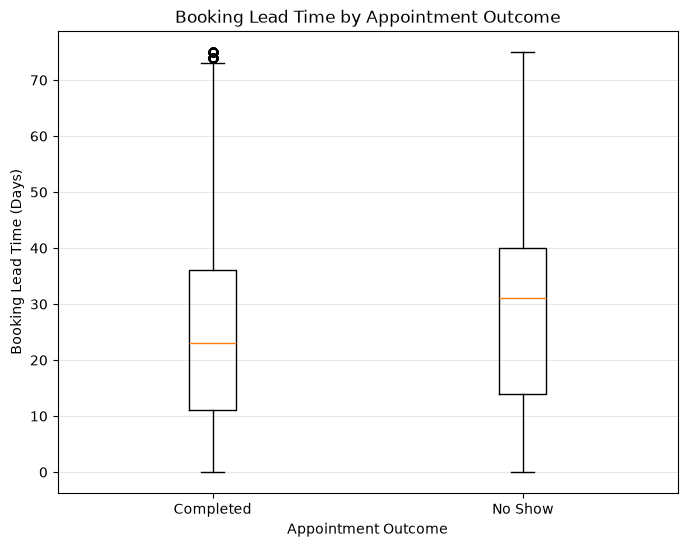

In [23]:
completed_lead = no_show_df.loc[
    no_show_df["AppointmentStatus"] == "Completed",
    "BookingLeadDays"
]

no_show_lead = no_show_df.loc[
    no_show_df["AppointmentStatus"] == "No Show",
    "BookingLeadDays"
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    [completed_lead, no_show_lead],
    tick_labels=["Completed", "No Show"]
)

plt.xlabel("Appointment Outcome")
plt.ylabel("Booking Lead Time (Days)")
plt.title("Booking Lead Time by Appointment Outcome")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Welch’s t-test + Mann–Whitney U Test

In [24]:
# Welch's independent t-test
t_stat, t_p = ttest_ind(
    completed_lead,
    no_show_lead,
    equal_var=False
)

# Mann-Whitney U test
u_stat, u_p = stats.mannwhitneyu(
    completed_lead,
    no_show_lead,
    alternative="two-sided"
)

print("Welch's Independent T-Test")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {t_p:.6f}")

print("\nMann-Whitney U Test")
print(f"U-statistic: {u_stat:.2f}")
print(f"p-value: {u_p:.6f}")

Welch's Independent T-Test
t-statistic: -18.026
p-value: 0.000000

Mann-Whitney U Test
U-statistic: 75380264.50
p-value: 0.000000


### Calculate Effect Size

In [25]:
mean_completed = completed_lead.mean()
mean_no_show = no_show_lead.mean()

std_completed = completed_lead.std(ddof=1)
std_no_show = no_show_lead.std(ddof=1)

n_completed = len(completed_lead)
n_no_show = len(no_show_lead)

pooled_std = np.sqrt(
    (
        (n_completed - 1) * std_completed**2
        +
        (n_no_show - 1) * std_no_show**2
    )
    /
    (n_completed + n_no_show - 2)
)

cohens_d = (
    mean_no_show - mean_completed
) / pooled_std

print(f"Mean difference: {mean_no_show - mean_completed:.2f} days")
print(f"Cohen's d: {cohens_d:.3f}")

Mean difference: 4.85 days
Cohen's d: 0.290


### Statistical Finding 3: Booking Lead Time vs Appointment No-Show

Completed and no-show appointments showed different booking lead-time
distributions.

- Completed appointments: mean = 24.97 days, median = 23 days
- No-show appointments: mean = 29.81 days, median = 31 days
- Mean difference = 4.85 days

Welch's independent t-test found a statistically significant difference in
average booking lead time between completed and no-show appointments
(t = -18.026, p < 0.001).

The Mann–Whitney U test also showed a statistically significant difference
between the booking lead-time distributions (p < 0.001).

However, the effect size was small (Cohen's d = 0.290).

Therefore, longer booking lead times were associated with appointment no-shows,
but booking lead time alone is unlikely to explain most no-show behavior.
Additional factors such as department, provider, appointment characteristics,
and patient-level factors may also contribute.

This analysis identifies association and does not establish causation.

## Statistical Analysis 4 — Chronic Condition Status vs Healthcare Utilization

### Load Patient-Level Utilization Data

In [26]:
chronic_utilization_query = """
WITH ChronicPatients AS
(
    SELECT DISTINCT
        f.PatientKey

    FROM dbo.fact_encounter AS f

    INNER JOIN dbo.fact_encounter_diagnosis AS ed
        ON f.EncounterKey = ed.EncounterKey

    INNER JOIN dbo.dim_diagnosis AS d
        ON ed.DiagnosisKey = d.DiagnosisKey

    WHERE
        f.PatientKey <> 0
        AND ed.DiagnosisKey <> 0
        AND d.ChronicConditionFlag = 1
),

PatientUtilization AS
(
    SELECT
        f.PatientKey,

        COUNT(*) AS TotalEncounters,

        SUM(
            CASE
                WHEN f.EncounterType = 'Emergency'
                THEN 1
                ELSE 0
            END
        ) AS EmergencyEncounters,

        AVG(f.WaitMinutes) AS AverageWaitMinutes,

        AVG(f.EncounterCost) AS AverageEncounterCost,

        SUM(f.EncounterCost) AS TotalEncounterCost

    FROM dbo.fact_encounter AS f

    WHERE
        f.PatientKey <> 0

    GROUP BY
        f.PatientKey
)

SELECT
    p.PatientKey,

    CASE
        WHEN c.PatientKey IS NOT NULL
            THEN 'Chronic Condition Patient'

        ELSE 'No Documented Chronic Condition'
    END AS PatientCohort,

    p.TotalEncounters,
    p.EmergencyEncounters,
    p.AverageWaitMinutes,
    p.AverageEncounterCost,
    p.TotalEncounterCost

FROM PatientUtilization AS p

LEFT JOIN ChronicPatients AS c
    ON p.PatientKey = c.PatientKey;
"""

chronic_utilization_df = pd.read_sql(
    chronic_utilization_query,
    engine
)

chronic_utilization_df.head(10)

,PatientKey,PatientCohort,TotalEncounters,EmergencyEncounters,AverageWaitMinutes,AverageEncounterCost,TotalEncounterCost
0,7162,Chronic Condition Patient,10,0,30.90,"3,101.58","31,015.83"
1,5834,Chronic Condition Patient,10,1,48.60,"6,177.06","61,770.65"
2,1589,Chronic Condition Patient,11,1,40.45,"7,098.92","70,989.23"
3,2917,Chronic Condition Patient,9,2,34.75,"2,637.28","23,735.54"
4,1566,Chronic Condition Patient,6,1,31.83,"1,027.52","6,165.11"
5,2894,Chronic Condition Patient,18,3,38.61,"2,571.07","46,279.29"
6,7185,Chronic Condition Patient,18,5,37.50,"3,208.23","57,748.16"
7,8513,Chronic Condition Patient,9,1,22.11,"2,824.18","25,417.60"
8,23,Chronic Condition Patient,6,0,21.67,552.05,"3,312.32"
9,215,Chronic Condition Patient,7,3,52.86,"1,131.68","7,921.76"


### Check Chronic vs Non-Chronic Patient Groups

In [27]:
print("Number of patients:", len(chronic_utilization_df))

print("\nPatient cohort counts:")
print(
    chronic_utilization_df["PatientCohort"]
    .value_counts()
)

print("\nMissing values:")
print(
    chronic_utilization_df[
        [
            "TotalEncounters",
            "EmergencyEncounters",
            "AverageWaitMinutes",
            "AverageEncounterCost",
            "TotalEncounterCost"
        ]
    ].isnull().sum()
)

print("\nUtilization summary by cohort:")

cohort_summary = (
    chronic_utilization_df
    .groupby("PatientCohort")
    .agg(
        Patients=("PatientKey", "count"),
        MeanEncounters=("TotalEncounters", "mean"),
        MedianEncounters=("TotalEncounters", "median"),
        MeanEmergencyEncounters=("EmergencyEncounters", "mean"),
        MeanAverageWait=("AverageWaitMinutes", "mean"),
        MeanAverageCost=("AverageEncounterCost", "mean"),
        MeanTotalCost=("TotalEncounterCost", "mean")
    )
    .round(2)
)

cohort_summary

Number of patients: 9972

Patient cohort counts:
PatientCohort
Chronic Condition Patient          9926
No Documented Chronic Condition      46
Name: count, dtype: int64

Missing values:
TotalEncounters         0
EmergencyEncounters     0
AverageWaitMinutes      0
AverageEncounterCost    0
TotalEncounterCost      0
dtype: int64

Utilization summary by cohort:


,Patients,MeanEncounters,MedianEncounters,MeanEmergencyEncounters,MeanAverageWait,MeanAverageCost,MeanTotalCost
PatientCohort,,,,,,,
Chronic Condition Patient,9926,9.04,8.50,1.28,36.42,"3,099.67","28,718.25"
No Documented Chronic Condition,46,3.00,3.00,0.39,35.34,"2,881.39","9,679.27"


### Investigate the Chronic Cohort

In [28]:
chronic_diagnostic_query = """
SELECT
    d.DiagnosisName,
    d.DiagnosisCategory,
    d.ChronicConditionFlag,

    COUNT(DISTINCT ed.EncounterKey) AS EncountersWithDiagnosis,

    COUNT(
        DISTINCT f.PatientKey
    ) AS UniquePatients

FROM dbo.fact_encounter_diagnosis AS ed

INNER JOIN dbo.dim_diagnosis AS d
    ON ed.DiagnosisKey = d.DiagnosisKey

INNER JOIN dbo.fact_encounter AS f
    ON ed.EncounterKey = f.EncounterKey

WHERE
    ed.DiagnosisKey <> 0
    AND f.PatientKey <> 0

GROUP BY
    d.DiagnosisName,
    d.DiagnosisCategory,
    d.ChronicConditionFlag

ORDER BY
    UniquePatients DESC;
"""

chronic_diagnosis_summary = pd.read_sql(
    chronic_diagnostic_query,
    engine
)

print("Number of diagnosis definitions:")
print(
    chronic_diagnosis_summary[
        "ChronicConditionFlag"
    ].value_counts()
)

chronic_diagnosis_summary.head(20)

Number of diagnosis definitions:
ChronicConditionFlag
1    31
0    18
Name: count, dtype: int64


,DiagnosisName,DiagnosisCategory,ChronicConditionFlag,EncountersWithDiagnosis,UniquePatients
0,Chest Pain,Other,0,11440,6419
1,Abdominal Pain,Other,0,8137,5525
2,Hypothyroidism,Other,1,7011,5030
3,Obesity,Other,1,6969,4982
4,Headache,Other,0,6968,4965
5,Anemia,Other,0,6838,4934
6,Hyperlipidemia,Other,1,6832,4907
7,Essential Hypertension,Hypertension,1,6109,3993
8,Asthma,Asthma,1,5145,3837
9,Chronic Obstructive Pulmonary Disease,COPD,1,5146,3818


### Build the Baseline Chronic Cohort

In [29]:
baseline_chronic_query = """
WITH AnalysisBoundary AS
(
    SELECT
        MAX(ArrivalDateTime) AS LastObservedDate
    FROM dbo.fact_encounter
),

FirstEncounter AS
(
    SELECT
        PatientKey,
        EncounterKey,
        ArrivalDateTime,

        ROW_NUMBER() OVER (
            PARTITION BY PatientKey
            ORDER BY ArrivalDateTime, EncounterKey
        ) AS rn

    FROM dbo.fact_encounter

    WHERE
        PatientKey <> 0
),

EligiblePatients AS
(
    SELECT
        f.PatientKey,
        f.EncounterKey AS IndexEncounterKey,
        f.ArrivalDateTime AS IndexDate

    FROM FirstEncounter AS f

    CROSS JOIN AnalysisBoundary AS b

    WHERE
        f.rn = 1

        AND DATEADD(
            DAY,
            365,
            f.ArrivalDateTime
        ) <= b.LastObservedDate
),

BaselineCohort AS
(
    SELECT
        e.PatientKey,
        e.IndexEncounterKey,
        e.IndexDate,

        CASE
            WHEN EXISTS
            (
                SELECT 1

                FROM dbo.fact_encounter_diagnosis AS ed

                INNER JOIN dbo.dim_diagnosis AS d
                    ON ed.DiagnosisKey = d.DiagnosisKey

                WHERE
                    ed.EncounterKey = e.IndexEncounterKey
                    AND ed.DiagnosisKey <> 0
                    AND d.ChronicConditionFlag = 1
            )

            THEN 'Baseline Chronic Condition'

            ELSE 'No Baseline Chronic Condition'
        END AS BaselineCohort

    FROM EligiblePatients AS e
)

SELECT
    BaselineCohort,
    COUNT(*) AS Patients

FROM BaselineCohort

GROUP BY
    BaselineCohort;
"""

baseline_cohort_counts = pd.read_sql(
    baseline_chronic_query,
    engine
)

baseline_cohort_counts

,BaselineCohort,Patients
0,Baseline Chronic Condition,4347
1,No Baseline Chronic Condition,1671


### Measure 365-Day Follow-Up Utilization

In [30]:
followup_utilization_query = """
WITH AnalysisBoundary AS
(
    SELECT
        MAX(ArrivalDateTime) AS LastObservedDate
    FROM dbo.fact_encounter
),

FirstEncounter AS
(
    SELECT
        PatientKey,
        EncounterKey,
        ArrivalDateTime,

        ROW_NUMBER() OVER (
            PARTITION BY PatientKey
            ORDER BY ArrivalDateTime, EncounterKey
        ) AS rn

    FROM dbo.fact_encounter

    WHERE
        PatientKey <> 0
),

EligiblePatients AS
(
    SELECT
        f.PatientKey,
        f.EncounterKey AS IndexEncounterKey,
        f.ArrivalDateTime AS IndexDate

    FROM FirstEncounter AS f

    CROSS JOIN AnalysisBoundary AS b

    WHERE
        f.rn = 1

        AND DATEADD(
            DAY,
            365,
            f.ArrivalDateTime
        ) <= b.LastObservedDate
),

BaselineCohort AS
(
    SELECT
        e.PatientKey,
        e.IndexEncounterKey,
        e.IndexDate,

        CASE
            WHEN EXISTS
            (
                SELECT 1

                FROM dbo.fact_encounter_diagnosis AS ed

                INNER JOIN dbo.dim_diagnosis AS d
                    ON ed.DiagnosisKey = d.DiagnosisKey

                WHERE
                    ed.EncounterKey = e.IndexEncounterKey
                    AND ed.DiagnosisKey <> 0
                    AND d.ChronicConditionFlag = 1
            )

            THEN 'Baseline Chronic Condition'

            ELSE 'No Baseline Chronic Condition'
        END AS BaselineCohort

    FROM EligiblePatients AS e
)

SELECT
    b.PatientKey,
    b.BaselineCohort,

    COUNT(
        f.EncounterKey
    ) AS FollowUpEncounters,

    SUM(
        CASE
            WHEN f.EncounterType = 'Emergency'
            THEN 1
            ELSE 0
        END
    ) AS FollowUpEmergencyEncounters,

    AVG(
        f.WaitMinutes
    ) AS FollowUpAverageWaitMinutes,

    SUM(
        COALESCE(f.EncounterCost, 0)
    ) AS FollowUpTotalEncounterCost

FROM BaselineCohort AS b

LEFT JOIN dbo.fact_encounter AS f
    ON b.PatientKey = f.PatientKey

    AND f.ArrivalDateTime > b.IndexDate

    AND f.ArrivalDateTime
        <= DATEADD(
            DAY,
            365,
            b.IndexDate
        )

GROUP BY
    b.PatientKey,
    b.BaselineCohort;
"""

followup_utilization_df = pd.read_sql(
    followup_utilization_query,
    engine
)

followup_utilization_df.head(10)

,PatientKey,BaselineCohort,FollowUpEncounters,FollowUpEmergencyEncounters,FollowUpAverageWaitMinutes,FollowUpTotalEncounterCost
0,6517,No Baseline Chronic Condition,4,0,18.25,"1,204.18"
1,8194,No Baseline Chronic Condition,5,1,31.80,"24,972.33"
2,6299,Baseline Chronic Condition,5,2,57.20,"24,407.20"
3,2220,Baseline Chronic Condition,6,0,17.50,"18,942.13"
4,416,Baseline Chronic Condition,3,0,29.67,"2,286.98"
5,8260,Baseline Chronic Condition,5,1,25.00,"29,044.39"
6,2044,No Baseline Chronic Condition,11,0,22.73,"42,620.23"
7,1515,Baseline Chronic Condition,5,0,37.00,"24,851.28"
8,6938,No Baseline Chronic Condition,3,2,58.67,"2,972.98"
9,9516,Baseline Chronic Condition,5,2,32.80,"16,915.79"


### Compare 365-Day Utilization by Baseline Cohort

In [31]:
followup_summary = (
    followup_utilization_df
    .groupby("BaselineCohort")
    .agg(
        Patients=("PatientKey", "count"),

        MeanFollowUpEncounters=("FollowUpEncounters", "mean"),
        MedianFollowUpEncounters=("FollowUpEncounters", "median"),

        MeanEmergencyEncounters=("FollowUpEmergencyEncounters", "mean"),
        MedianEmergencyEncounters=("FollowUpEmergencyEncounters", "median"),

        MeanTotalEncounterCost=("FollowUpTotalEncounterCost", "mean"),
        MedianTotalEncounterCost=("FollowUpTotalEncounterCost", "median"),

        MeanAverageWaitMinutes=("FollowUpAverageWaitMinutes", "mean")
    )
    .round(2)
)

followup_summary

,Patients,MeanFollowUpEncounters,MedianFollowUpEncounters,MeanEmergencyEncounters,MedianEmergencyEncounters,MeanTotalEncounterCost,MedianTotalEncounterCost,MeanAverageWaitMinutes
BaselineCohort,,,,,,,,
Baseline Chronic Condition,4347,4.87,4.00,0.68,0.00,"15,666.28","12,140.84",36.33
No Baseline Chronic Condition,1671,4.62,4.00,0.64,0.00,"14,806.54","10,753.05",35.77


### Check Follow-Up Encounter Count Distribution

In [32]:
encounter_count_summary = (
    followup_utilization_df
    .groupby("BaselineCohort")["FollowUpEncounters"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Variance="var",
        StdDev="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

encounter_count_summary["VarianceToMeanRatio"] = (
    encounter_count_summary["Variance"]
    /
    encounter_count_summary["Mean"]
).round(2)

encounter_count_summary

,Count,Mean,Median,Variance,StdDev,Minimum,Maximum,VarianceToMeanRatio
BaselineCohort,,,,,,,,
Baseline Chronic Condition,4347,4.87,4.00,9.13,3.02,0,20,1.87
No Baseline Chronic Condition,1671,4.62,4.00,8.56,2.93,0,18,1.85


### Negative Binomial Model: Baseline Chronic Status vs Future

In [34]:
import statsmodels.formula.api as smf

nb_df = followup_utilization_df[
    [
        "BaselineCohort",
        "FollowUpEncounters"
    ]
].copy()

nb_df["BaselineChronicFlag"] = np.where(
    nb_df["BaselineCohort"] == "Baseline Chronic Condition",
    1,
    0
)

nb_model = smf.negativebinomial(
    "FollowUpEncounters ~ BaselineChronicFlag",
    data=nb_df
).fit(
    disp=False
)

nb_model.summary()

chronic_coef = nb_model.params["BaselineChronicFlag"]
chronic_p = nb_model.pvalues["BaselineChronicFlag"]

incidence_rate_ratio = np.exp(chronic_coef)

confidence_interval = nb_model.conf_int().loc[
    "BaselineChronicFlag"
]

irr_lower = np.exp(confidence_interval.iloc[0])
irr_upper = np.exp(confidence_interval.iloc[1])

print("\nBaseline Chronic Condition Effect")
print(f"Coefficient: {chronic_coef:.4f}")
print(f"p-value: {chronic_p:.4f}")
print(f"Incidence Rate Ratio (IRR): {incidence_rate_ratio:.3f}")
print(
    f"95% CI for IRR: "
    f"{irr_lower:.3f} to {irr_upper:.3f}"
)


Baseline Chronic Condition Effect
Coefficient: 0.0538
p-value: 0.0026
Incidence Rate Ratio (IRR): 1.055
95% CI for IRR: 1.019 to 1.093


### Statistical Finding 4: Baseline Chronic Condition Status vs Future Utilization

The original lifetime chronic-condition comparison produced an extremely
imbalanced cohort because patients with more encounters had more opportunities
to receive a chronic diagnosis.

To reduce this bias, chronic-condition status was redefined using only the
patient's first observed encounter. Patients were then followed for a fixed
365-day observation window.

The final cohorts included:

- Baseline chronic condition: 4,347 patients
- No baseline chronic condition: 1,671 patients

During the following 365 days, patients with a baseline chronic condition had
slightly higher encounter utilization:

- Mean follow-up encounters: 4.87 vs 4.62
- Median follow-up encounters: 4 vs 4

Encounter counts showed moderate overdispersion, with variance-to-mean ratios
of approximately 1.87 and 1.85. Therefore, negative binomial regression was
used instead of a simple Poisson model.

Baseline chronic-condition status was associated with a statistically
significant but modest increase in future encounter utilization
(IRR = 1.055, 95% CI 1.019–1.093, p = 0.0026).

This corresponds to approximately 5.5% higher expected encounter utilization
during the 365-day follow-up period for patients with a chronic condition
documented at baseline.

The effect size was small, suggesting that chronic-condition status alone
explains only a limited portion of future healthcare utilization.

This analysis identifies association and does not establish causation.

## Statistical Analysis 5 — Follow-Up Completion vs 30-Day Readmission

### Build the Follow-Up vs Readmission Dataset

In [35]:
followup_readmission_query = """
WITH AnalysisBoundary AS
(
    SELECT
        MAX(AdmissionDateTime) AS LastObservedAdmissionDate
    FROM dbo.fact_admission
),

AdmissionSequence AS
(
    SELECT
        AdmissionKey,
        PatientKey,
        AdmissionDateTime,
        DischargeDateTime,
        FollowUpRequiredFlag,
        FollowUpCompletedFlag,

        LEAD(AdmissionDateTime)
        OVER (
            PARTITION BY PatientKey
            ORDER BY
                AdmissionDateTime,
                AdmissionKey
        ) AS NextAdmissionDateTime

    FROM dbo.fact_admission

    WHERE
        PatientKey <> 0
        AND DischargeDateTime IS NOT NULL
),

EligibleAdmissions AS
(
    SELECT
        a.AdmissionKey,
        a.PatientKey,
        a.FollowUpCompletedFlag,

        CASE
            WHEN
                a.NextAdmissionDateTime > a.DischargeDateTime
                AND a.NextAdmissionDateTime
                    <= DATEADD(
                        DAY,
                        30,
                        a.DischargeDateTime
                    )
            THEN 1
            ELSE 0
        END AS ReadmissionWithin30DaysFlag

    FROM AdmissionSequence AS a

    CROSS JOIN AnalysisBoundary AS b

    WHERE
        DATEADD(
            DAY,
            30,
            a.DischargeDateTime
        ) <= b.LastObservedAdmissionDate

        AND a.FollowUpRequiredFlag = 1
)

SELECT
    AdmissionKey,
    PatientKey,
    FollowUpCompletedFlag,
    ReadmissionWithin30DaysFlag

FROM EligibleAdmissions;
"""

followup_readmission_df = pd.read_sql(
    followup_readmission_query,
    engine
)

followup_readmission_df.head(10)

,AdmissionKey,PatientKey,FollowUpCompletedFlag,ReadmissionWithin30DaysFlag
0,14497,2,1,0
1,4556,2,0,0
2,5027,3,1,0
3,5237,4,1,0
4,17424,5,1,0
5,17075,7,1,0
6,17372,8,1,0
7,8494,11,1,0
8,12097,12,1,0
9,12477,12,0,0


### Build the Contingency Table

In [36]:
contingency_table = pd.crosstab(
    followup_readmission_df["FollowUpCompletedFlag"],
    followup_readmission_df["ReadmissionWithin30DaysFlag"]
)

contingency_table.index = [
    "Follow-Up Not Completed",
    "Follow-Up Completed"
]

contingency_table.columns = [
    "Not Readmitted",
    "Readmitted Within 30 Days"
]

contingency_table

,Not Readmitted,Readmitted Within 30 Days
Follow-Up Not Completed,3221,590
Follow-Up Completed,7097,1072


### Chi-Square Test of Independence

In [37]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Test of Independence")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")

print("\nExpected frequencies:")
print(
    pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns
    ).round(2)
)

Chi-Square Test of Independence
Chi-square statistic: 11.904
Degrees of freedom: 1
p-value: 0.000560

Expected frequencies:
                         Not Readmitted  Readmitted Within 30 Days
Follow-Up Not Completed        3,282.30                     528.70
Follow-Up Completed            7,035.70                   1,133.30


### Calculate Risk Ratio

In [38]:
not_completed = followup_readmission_df[
    followup_readmission_df["FollowUpCompletedFlag"] == 0
]

completed = followup_readmission_df[
    followup_readmission_df["FollowUpCompletedFlag"] == 1
]

risk_not_completed = (
    not_completed["ReadmissionWithin30DaysFlag"].mean()
)

risk_completed = (
    completed["ReadmissionWithin30DaysFlag"].mean()
)

risk_ratio = (
    risk_not_completed
    /
    risk_completed
)

risk_difference = (
    risk_not_completed
    -
    risk_completed
)

# 95% confidence interval for risk ratio
a = not_completed["ReadmissionWithin30DaysFlag"].sum()
n1 = len(not_completed)

c = completed["ReadmissionWithin30DaysFlag"].sum()
n0 = len(completed)

se_log_rr = np.sqrt(
    (1 / a) - (1 / n1)
    +
    (1 / c) - (1 / n0)
)

lower_ci = np.exp(
    np.log(risk_ratio) - 1.96 * se_log_rr
)

upper_ci = np.exp(
    np.log(risk_ratio) + 1.96 * se_log_rr
)

print(f"Readmission risk - Follow-Up Not Completed: {risk_not_completed * 100:.2f}%")
print(f"Readmission risk - Follow-Up Completed: {risk_completed * 100:.2f}%")

print(f"\nRisk Difference: {risk_difference * 100:.2f} percentage points")

print(f"Risk Ratio: {risk_ratio:.3f}")
print(f"95% CI for Risk Ratio: {lower_ci:.3f} to {upper_ci:.3f}")

Readmission risk - Follow-Up Not Completed: 15.48%
Readmission risk - Follow-Up Completed: 13.12%

Risk Difference: 2.36 percentage points
Risk Ratio: 1.180
95% CI for Risk Ratio: 1.075 to 1.294


### Statistical Finding 5: Follow-Up Completion vs 30-Day Readmission

Among eligible admissions where post-discharge follow-up was required:

- Follow-up not completed: 590 readmissions out of 3,811 admissions (15.48%)
- Follow-up completed: 1,072 readmissions out of 8,169 admissions (13.12%)

A Chi-Square Test of Independence identified a statistically significant
association between follow-up completion status and 30-day readmission
(χ² = 11.904, df = 1, p = 0.000560).

Admissions without completed follow-up had a 30-day readmission risk that was
approximately 18% higher than admissions where required follow-up was completed
(RR = 1.180, 95% CI 1.075–1.294).

The absolute difference in readmission risk was 2.36 percentage points.

These findings suggest that incomplete follow-up is associated with higher
observed readmission risk. However, the analysis is observational and does not
establish that follow-up completion itself causes lower readmission rates.
Patient complexity, disease severity, discharge disposition, and other factors
may contribute to the observed association.

## Statistical Analysis 6 — Length of Stay vs 30-Day Readmission

### Load LOS + Readmission Dataset

In [50]:
los_readmission_query = """
WITH AnalysisBoundary AS
(
    SELECT
        MAX(AdmissionDateTime) AS LastObservedAdmissionDate
    FROM dbo.fact_admission
),

AdmissionSequence AS
(
    SELECT
        AdmissionKey,
        PatientKey,
        AdmissionDateTime,
        DischargeDateTime,
        LengthOfStayDays,

        LEAD(AdmissionDateTime)
        OVER (
            PARTITION BY PatientKey
            ORDER BY
                AdmissionDateTime,
                AdmissionKey
        ) AS NextAdmissionDateTime

    FROM dbo.fact_admission

    WHERE
        PatientKey <> 0
        AND DischargeDateTime IS NOT NULL
        AND LengthOfStayDays IS NOT NULL
),

EligibleAdmissions AS
(
    SELECT
        a.AdmissionKey,
        a.PatientKey,
        a.LengthOfStayDays,

        CASE
            WHEN
                a.NextAdmissionDateTime > a.DischargeDateTime
                AND a.NextAdmissionDateTime
                    <= DATEADD(
                        DAY,
                        30,
                        a.DischargeDateTime
                    )
            THEN 1
            ELSE 0
        END AS ReadmissionWithin30DaysFlag

    FROM AdmissionSequence AS a

    CROSS JOIN AnalysisBoundary AS b

    WHERE
        DATEADD(
            DAY,
            30,
            a.DischargeDateTime
        ) <= b.LastObservedAdmissionDate
)

SELECT
    AdmissionKey,
    PatientKey,
    LengthOfStayDays,
    ReadmissionWithin30DaysFlag

FROM EligibleAdmissions;
"""

los_readmission_df = pd.read_sql(
    los_readmission_query,
    engine
)

los_readmission_df.head(10)

,AdmissionKey,PatientKey,LengthOfStayDays,ReadmissionWithin30DaysFlag
0,14497,2,1.68,0
1,6446,2,5.33,0
2,4556,2,1.60,0
3,5027,3,6.48,0
4,5237,4,4.25,0
5,17424,5,1.41,0
6,12149,6,1.65,0
7,17075,7,3.34,0
8,17372,8,1.13,0
9,8494,11,3.44,0


### Compare Length of Stay by Readmission Outcome

In [51]:
los_summary = (
    los_readmission_df
    .groupby("ReadmissionWithin30DaysFlag")["LengthOfStayDays"]
    .agg(
        Admissions="count",
        MeanLOS="mean",
        MedianLOS="median",
        StdDev="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

los_summary.index = [
    "Not Readmitted",
    "Readmitted Within 30 Days"
]

los_summary

,Admissions,MeanLOS,MedianLOS,StdDev,Minimum,Maximum
Not Readmitted,13175,3.98,3.97,1.75,0.03,7.09
Readmitted Within 30 Days,2070,3.93,3.86,1.75,0.10,7.12


### Investigate Extreme LOS Values

In [41]:
print("LOS percentiles:")

print(
    los_readmission_df["LengthOfStayDays"]
    .quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
    )
    .round(2)
)

print("\nTop 10 longest stays:")

los_readmission_df.nlargest(
    10,
    "LengthOfStayDays"
)[
    [
        "AdmissionKey",
        "PatientKey",
        "LengthOfStayDays",
        "ReadmissionWithin30DaysFlag"
    ]
]

LOS percentiles:
0.50     3.97
0.75     5.49
0.90     6.42
0.95     6.73
0.99     6.98
0.99     7.01
1.00   208.47
Name: LengthOfStayDays, dtype: float64

Top 10 longest stays:


,AdmissionKey,PatientKey,LengthOfStayDays,ReadmissionWithin30DaysFlag
14773,17711,9708,208.47,0
9382,4885,6201,119.14,0
7546,10723,5027,90.69,0
12622,2019,8354,31.32,0
14624,15229,9604,7.12,1
13699,15666,9021,7.09,0
5188,1682,3499,7.08,0
4153,11503,2825,7.08,0
13800,9506,9079,7.07,0
8387,12634,5558,7.07,0


### Validate the Extreme LOS Values Against Timestamps

In [42]:
los_validation_query = """
SELECT
    a.AdmissionKey,
    a.AdmissionID,
    a.PatientKey,
    a.EncounterKey,

    a.AdmissionDateTime,
    a.DischargeDateTime,

    a.LengthOfStayDays AS StoredLengthOfStayDays,

    ROUND(
        DATEDIFF(
            MINUTE,
            a.AdmissionDateTime,
            a.DischargeDateTime
        ) / 1440.0,
        2
    ) AS RecalculatedLengthOfStayDays,

    f.EncounterEndRecoveredFlag

FROM dbo.fact_admission AS a

LEFT JOIN dbo.fact_encounter AS f
    ON a.EncounterKey = f.EncounterKey

WHERE
    a.LengthOfStayDays > 10

ORDER BY
    a.LengthOfStayDays DESC;
"""

los_validation_df = pd.read_sql(
    los_validation_query,
    engine
)

los_validation_df

,AdmissionKey,AdmissionID,PatientKey,EncounterKey,AdmissionDateTime,DischargeDateTime,StoredLengthOfStayDays,RecalculatedLengthOfStayDays,EncounterEndRecoveredFlag
0,14716,ADM014716,2094,74434,2023-04-22 20:35:00,2026-08-28 22:11:48,"1,224.07","1,224.07",0
1,12344,ADM012344,506,62689,2023-05-16 16:46:00,2026-08-28 05:59:54,"1,199.55","1,199.55",0
2,15123,ADM015123,5426,76577,2023-10-30 20:57:00,2026-08-28 17:49:00,"1,032.87","1,032.87",0
3,13040,ADM013040,1237,66217,2023-12-05 08:13:00,2026-08-28 08:31:48,997.01,997.01,0
4,12677,ADM012677,4978,64241,2024-01-13 19:11:00,2026-08-28 18:22:42,957.97,957.97,0
...,...,...,...,...,...,...,...,...,...
74,4885,ADM004885,6201,25185,2025-03-07 15:16:00,2025-07-04 18:33:24,119.14,119.14,1
75,10723,ADM010723,5027,54092,2025-06-09 10:07:00,2025-09-08 02:38:24,90.69,90.69,1
76,818,ADM000818,4983,4313,2025-10-12 09:36:00,2025-12-12 00:15:48,60.61,60.61,1
77,2019,ADM002019,8354,10546,2025-08-09 13:38:00,2025-09-09 21:15:18,31.32,31.32,1


### Check Whether Admission Discharge Came From Encounter End Time

In [43]:
extreme_los_lineage_query = """
SELECT
    a.AdmissionKey,
    a.AdmissionID,
    a.PatientKey,
    a.EncounterKey,

    a.AdmissionDateTime,
    a.DischargeDateTime,
    a.LengthOfStayDays,

    f.ArrivalDateTime,
    f.EncounterEndDateTime,
    f.EncounterEndRecoveredFlag,

    DATEDIFF(
        MINUTE,
        a.DischargeDateTime,
        f.EncounterEndDateTime
    ) AS DischargeVsEncounterEndMinutes,

    CASE
        WHEN a.DischargeDateTime = f.EncounterEndDateTime
        THEN 1
        ELSE 0
    END AS DischargeMatchesEncounterEndFlag

FROM dbo.fact_admission AS a

LEFT JOIN dbo.fact_encounter AS f
    ON a.EncounterKey = f.EncounterKey

WHERE
    a.LengthOfStayDays > 10

ORDER BY
    a.LengthOfStayDays DESC;
"""

extreme_los_lineage_df = pd.read_sql(
    extreme_los_lineage_query,
    engine
)

extreme_los_lineage_df.head(20)

,AdmissionKey,AdmissionID,PatientKey,EncounterKey,AdmissionDateTime,DischargeDateTime,LengthOfStayDays,ArrivalDateTime,EncounterEndDateTime,EncounterEndRecoveredFlag,DischargeVsEncounterEndMinutes,DischargeMatchesEncounterEndFlag
0,14716,ADM014716,2094,74434,2023-04-22 20:35:00,2026-08-28 22:11:48,"1,224.07",2023-04-22 20:35:00,2026-08-28 22:11:48,0,0,1
1,12344,ADM012344,506,62689,2023-05-16 16:46:00,2026-08-28 05:59:54,"1,199.55",2023-05-16 16:46:00,2026-08-28 05:59:54,0,0,1
2,15123,ADM015123,5426,76577,2023-10-30 20:57:00,2026-08-28 17:49:00,"1,032.87",2023-10-30 20:57:00,2026-08-28 17:49:00,0,0,1
3,13040,ADM013040,1237,66217,2023-12-05 08:13:00,2026-08-28 08:31:48,997.01,2023-12-05 08:13:00,2026-08-28 08:31:48,0,0,1
4,12677,ADM012677,4978,64241,2024-01-13 19:11:00,2026-08-28 18:22:42,957.97,2024-01-13 19:11:00,2026-08-28 18:22:42,0,0,1
5,4104,ADM004104,2847,21215,2024-01-23 13:39:00,2026-08-28 12:37:48,947.96,2024-01-23 13:39:00,2026-08-28 12:37:48,0,0,1
6,6199,ADM006199,2405,31688,2024-02-06 13:25:00,2026-08-28 11:11:12,933.91,2024-02-06 13:25:00,2026-08-28 11:11:12,0,0,1
7,4548,ADM004548,1939,23536,2024-04-30 06:31:00,2026-08-28 05:13:54,849.95,2024-04-30 06:31:00,2026-08-28 05:13:54,0,0,1
8,8687,ADM008687,3043,43747,2024-05-29 12:28:00,2026-08-28 08:42:48,820.84,2024-05-29 12:28:00,2026-08-28 08:42:48,0,0,1
9,9651,ADM009651,6492,48771,2024-07-15 11:13:00,2026-08-28 14:05:06,774.12,2024-07-15 11:13:00,2026-08-28 14:05:06,0,0,1


In [44]:
print(
    extreme_los_lineage_df[
        "DischargeMatchesEncounterEndFlag"
    ].value_counts()
)

print("\nRecovered encounter ends:")
print(
    extreme_los_lineage_df[
        "EncounterEndRecoveredFlag"
    ].value_counts()
)

DischargeMatchesEncounterEndFlag
1    79
Name: count, dtype: int64

Recovered encounter ends:
EncounterEndRecoveredFlag
0    73
1     6
Name: count, dtype: int64


### Check Where the Suspicious End Dates Are Concentrated

In [45]:
extreme_end_date_summary_query = """
SELECT
    CAST(
        f.EncounterEndDateTime AS DATE
    ) AS EncounterEndDate,

    f.EncounterEndRecoveredFlag,

    COUNT(*) AS ExtremeAdmissions,

    MIN(a.AdmissionDateTime) AS EarliestAdmission,

    MAX(a.AdmissionDateTime) AS LatestAdmission,

    ROUND(
        AVG(a.LengthOfStayDays),
        2
    ) AS AverageLOS,

    ROUND(
        MAX(a.LengthOfStayDays),
        2
    ) AS MaximumLOS

FROM dbo.fact_admission AS a

INNER JOIN dbo.fact_encounter AS f
    ON a.EncounterKey = f.EncounterKey

WHERE
    a.LengthOfStayDays > 10

GROUP BY
    CAST(
        f.EncounterEndDateTime AS DATE
    ),
    f.EncounterEndRecoveredFlag

ORDER BY
    ExtremeAdmissions DESC,
    EncounterEndDate DESC;
"""

extreme_end_date_summary = pd.read_sql(
    extreme_end_date_summary_query,
    engine
)

extreme_end_date_summary

,EncounterEndDate,EncounterEndRecoveredFlag,ExtremeAdmissions,EarliestAdmission,LatestAdmission,AverageLOS,MaximumLOS
0,2026-08-28,0,73,2023-04-22 20:35:00,2025-12-29 21:19:00,493.73,"1,224.07"
1,2025-12-13,1,1,2025-11-12 10:03:00,2025-11-12 10:03:00,31.04,31.04
2,2025-12-12,1,1,2025-10-12 09:36:00,2025-10-12 09:36:00,60.61,60.61
3,2025-10-05,1,1,2025-03-10 22:55:00,2025-03-10 22:55:00,208.47,208.47
4,2025-09-09,1,1,2025-08-09 13:38:00,2025-08-09 13:38:00,31.32,31.32
5,2025-09-08,1,1,2025-06-09 10:07:00,2025-06-09 10:07:00,90.69,90.69
6,2025-07-04,1,1,2025-03-07 15:16:00,2025-03-07 15:16:00,119.14,119.14


### Find the Relevant Encounter-End Columns

In [46]:
end_columns_query = """
SELECT
    COLUMN_NAME,
    DATA_TYPE

FROM INFORMATION_SCHEMA.COLUMNS

WHERE
    TABLE_SCHEMA = 'dbo'
    AND TABLE_NAME = 'fact_encounter'

    AND
    (
        COLUMN_NAME LIKE '%End%'
        OR COLUMN_NAME LIKE '%Duration%'
        OR COLUMN_NAME LIKE '%Recover%'
        OR COLUMN_NAME LIKE '%Source%'
    )

ORDER BY
    ORDINAL_POSITION;
"""

end_columns_df = pd.read_sql(
    end_columns_query,
    engine
)

end_columns_df

,COLUMN_NAME,DATA_TYPE
0,EncounterEndDateTime,datetime2
1,EncounterDurationHours,decimal
2,DepartmentIDRecoveredFlag,tinyint
3,EncounterDurationValidFlag,tinyint
4,EncounterEndRecoveredFlag,tinyint


### Inspect the Raw Encounter-End Values

In [47]:
from pathlib import Path

raw_encounters_path = Path("../data/raw/encounters.csv")

raw_encounters = pd.read_csv(
    raw_encounters_path,
    dtype=str
)

print("Raw encounter columns related to end time / duration:")

[
    col
    for col in raw_encounters.columns
    if any(
        word.lower() in col.lower()
        for word in [
            "end",
            "duration",
            "arrival"
        ]
    )
]

Raw encounter columns related to end time / duration:


['ArrivalDateTime', 'EncounterEndDateTime']

### Inspect the 73 Original Raw Encounter-End Values

In [48]:
affected_encounters_query = """
SELECT
    f.EncounterID,
    f.ArrivalDateTime AS WarehouseArrivalDateTime,
    f.EncounterEndDateTime AS WarehouseEncounterEndDateTime,
    f.EncounterEndRecoveredFlag,
    a.LengthOfStayDays

FROM dbo.fact_admission AS a

INNER JOIN dbo.fact_encounter AS f
    ON a.EncounterKey = f.EncounterKey

WHERE
    a.LengthOfStayDays > 10

    AND f.EncounterEndRecoveredFlag = 0

    AND CAST(
        f.EncounterEndDateTime AS DATE
    ) = '2026-08-28'

ORDER BY
    a.LengthOfStayDays DESC;
"""

affected_encounters = pd.read_sql(
    affected_encounters_query,
    engine
)

raw_comparison = affected_encounters.merge(
    raw_encounters[
        [
            "EncounterID",
            "ArrivalDateTime",
            "EncounterEndDateTime"
        ]
    ],
    on="EncounterID",
    how="left"
)

raw_comparison = raw_comparison.rename(
    columns={
        "ArrivalDateTime": "RawArrivalDateTime",
        "EncounterEndDateTime": "RawEncounterEndDateTime"
    }
)

print("Affected rows:", len(raw_comparison))

raw_comparison[
    [
        "EncounterID",
        "RawArrivalDateTime",
        "RawEncounterEndDateTime",
        "WarehouseEncounterEndDateTime",
        "LengthOfStayDays"
    ]
].head(20)

Affected rows: 73


,EncounterID,RawArrivalDateTime,RawEncounterEndDateTime,WarehouseEncounterEndDateTime,LengthOfStayDays
0,ENC074434,22-04-2023 20:35,22:11.8,2026-08-28 22:11:48,"1,224.07"
1,ENC062689,16-05-2023 16:46,05:59.9,2026-08-28 05:59:54,"1,199.55"
2,ENC076577,30-10-2023 20:57,17:49.0,2026-08-28 17:49:00,"1,032.87"
3,ENC066217,05-12-2023 08:13,08:31.8,2026-08-28 08:31:48,997.01
4,ENC064241,13-01-2024 19:11,18:22.7,2026-08-28 18:22:42,957.97
5,ENC021215,23-01-2024 13:39,12:37.8,2026-08-28 12:37:48,947.96
6,ENC031688,06-02-2024 13:25,11:11.2,2026-08-28 11:11:12,933.91
7,ENC023536,30-04-2024 06:31,05:13.9,2026-08-28 05:13:54,849.95
8,ENC043747,29-05-2024 12:28,08:42.8,2026-08-28 08:42:48,820.84
9,ENC048771,15-07-2024 11:13,14:05.1,2026-08-28 14:05:06,774.12


In [49]:
raw_duration_test = raw_encounters.copy()

duration_parts_all = (
    raw_duration_test["EncounterEndDateTime"]
    .astype("string")
    .str.strip()
    .str.extract(
        r"^(?P<Hours>\d+):(?P<Minutes>\d{2})\.(?P<Fraction>\d+)$"
    )
)

raw_duration_test["Hours"] = pd.to_numeric(
    duration_parts_all["Hours"],
    errors="coerce"
)

raw_duration_test["Minutes"] = pd.to_numeric(
    duration_parts_all["Minutes"],
    errors="coerce"
)

raw_duration_test["Fraction"] = pd.to_numeric(
    duration_parts_all["Fraction"],
    errors="coerce"
)

print("Total raw encounters:", len(raw_duration_test))

print(
    "Rows matching duration format:",
    duration_parts_all["Hours"].notna().sum()
)

print(
    "Rows NOT matching duration format:",
    duration_parts_all["Hours"].isna().sum()
)

print("\nHour distribution:")
print(
    raw_duration_test["Hours"]
    .describe()
)

print(
    "\nRows with duration hours >= 24:",
    (raw_duration_test["Hours"] >= 24).sum()
)

print(
    "Rows with duration hours < 24:",
    (raw_duration_test["Hours"] < 24).sum()
)

Total raw encounters: 90000
Rows matching duration format: 90000
Rows NOT matching duration format: 0

Hour distribution:
count   90,000.00
mean        29.53
std         17.34
min          0.00
25%         15.00
50%         30.00
75%         45.00
max         59.00
Name: Hours, dtype: Float64

Rows with duration hours >= 24: 54023
Rows with duration hours < 24: 35977


### Logistic Regression: LOS vs 30-Day Readmission

In [54]:
import statsmodels.api as sm

logit_df = los_readmission_df[
    [
        "LengthOfStayDays",
        "ReadmissionWithin30DaysFlag"
    ]
].dropna().copy()

X = sm.add_constant(
    logit_df["LengthOfStayDays"]
)

y = logit_df[
    "ReadmissionWithin30DaysFlag"
]

los_logit_model = sm.Logit(
    y,
    X
).fit(
    disp=False
)

los_logit_model.summary()

los_coef = los_logit_model.params[
    "LengthOfStayDays"
]

los_p = los_logit_model.pvalues[
    "LengthOfStayDays"
]

los_odds_ratio = np.exp(
    los_coef
)

los_ci = los_logit_model.conf_int().loc[
    "LengthOfStayDays"
]

los_or_lower = np.exp(
    los_ci.iloc[0]
)

los_or_upper = np.exp(
    los_ci.iloc[1]
)

print("\nLength of Stay Effect")
print(f"Coefficient: {los_coef:.4f}")
print(f"p-value: {los_p:.4f}")
print(f"Odds Ratio: {los_odds_ratio:.3f}")
print(
    f"95% CI for Odds Ratio: "
    f"{los_or_lower:.3f} to {los_or_upper:.3f}"
)


Length of Stay Effect
Coefficient: -0.0169
p-value: 0.2116
Odds Ratio: 0.983
95% CI for Odds Ratio: 0.958 to 1.010


### Statistical Finding 6: Length of Stay vs 30-Day Readmission

After correcting an upstream encounter-end timestamp parsing issue, length of
stay was recalculated from validated admission and discharge timestamps.

The corrected LOS distributions were very similar between the two readmission
groups:

- Not readmitted: mean LOS = 3.98 days, median = 3.97 days
- Readmitted within 30 days: mean LOS = 3.93 days, median = 3.86 days

An unadjusted logistic regression was used to evaluate whether length of stay
was associated with 30-day readmission.

The estimated odds ratio was 0.983 per additional LOS day
(95% CI 0.958–1.010, p = 0.2116).

Because the p-value was greater than 0.05 and the confidence interval included
1.00, there was no statistically significant evidence that length of stay was
associated with 30-day readmission in this dataset.

The estimated effect was also very small, with each additional LOS day
corresponding to approximately 1.7% lower estimated readmission odds.

This is an unadjusted observational analysis and does not account for potential
confounders such as disease severity, chronic conditions, discharge
disposition, department, or follow-up completion.

## Statistical Analysis Summary

Statistical analysis was performed to evaluate selected relationships identified
during the descriptive and root-cause analysis phases.

The analysis included correlation testing, within-department comparisons,
Welch's t-test, Mann–Whitney U testing, effect-size estimation, negative
binomial regression, Chi-Square testing, risk-ratio estimation, and logistic
regression.

Key findings showed that:

- Encounter volume and provider workload did not meaningfully explain
  month-to-month wait-time variation within departments.
- Longer booking lead times were associated with appointment no-shows,
  although the effect size was small.
- Baseline chronic-condition status was associated with a modest increase in
  subsequent 365-day encounter utilization.
- Incomplete required follow-up was associated with higher observed 30-day
  readmission risk.
- Length of stay was not significantly associated with 30-day readmission.

All analyses are observational and are intended for operational and population
health analytics. Associations should not be interpreted as causal effects or
clinical decision rules.